# Análise Topológica da Rede

Como o objetivo é estudar o ecossistema do reddit, moldamos um grafo que conecta subreddits a partir de autores que estes compartilham em comum.

Dessa forma, conseguimos estudar diversas questões, como:
1. Se os subreddits são individuais ou se há comunidades que englobam diferentes subreddits;
2. Quais os subreddits centrais da rede

In [1]:
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [2]:
g = ig.Graph.Read_GraphML("../data/processed/grafo.graphml")
print(f"Quantidade de nós: {g.vcount()}")
print(f"Quantidade de arestas: {g.ecount()}")


Quantidade de nós: 7372
Quantidade de arestas: 26432847


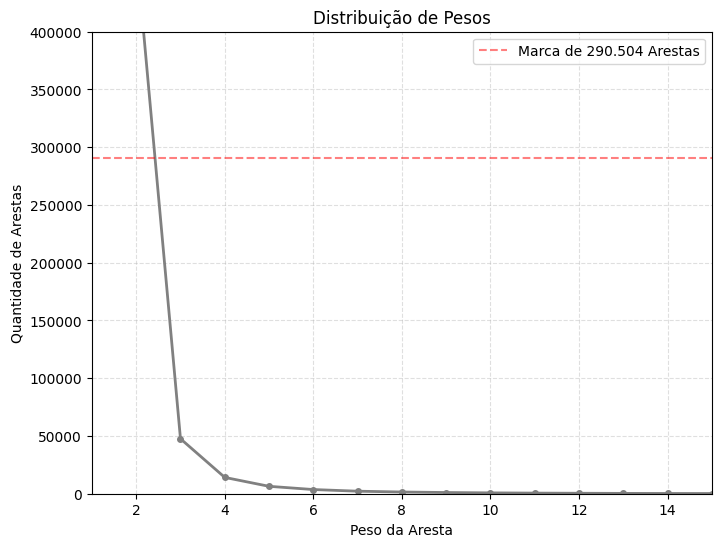

In [3]:
from collections import Counter
import matplotlib.pyplot as plt

counter_pesos = Counter(g.es["weight"])
pesos_ordenados = sorted(counter_pesos.items()) 

x = [item[0] for item in pesos_ordenados]
y = [item[1] for item in pesos_ordenados]

plt.figure(figsize=(8, 6))
plt.plot(x, y, linewidth=2, color='gray', marker='o', markersize=4)
plt.ylim(0, 400000) 
plt.xlim(1, 15) 

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.xlabel("Peso da Aresta")
plt.ylabel("Quantidade de Arestas")
plt.title("Distribuição de Pesos")

plt.axhline(y=290504, color='r', linestyle='--', alpha=0.5, label='Marca de 290.504 Arestas')
plt.legend()

plt.show()

/tmp/ipykernel_4185820/3942403460.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counter_pesos.keys()), y=list(counter_pesos.values()), palette="viridis")


(0.0, 10.0)

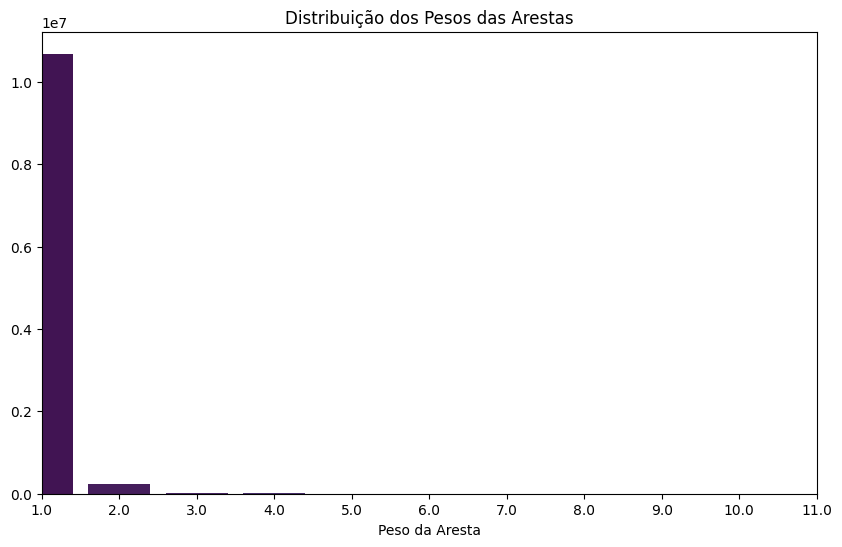

In [4]:
counter_pesos = Counter(g.es["weight"])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counter_pesos.keys()), y=list(counter_pesos.values()), palette="viridis")
plt.title("Distribuição dos Pesos das Arestas")
plt.xlabel("Peso da Aresta")
plt.xlim(0,10)

Text(0, 0.5, 'Frequência')

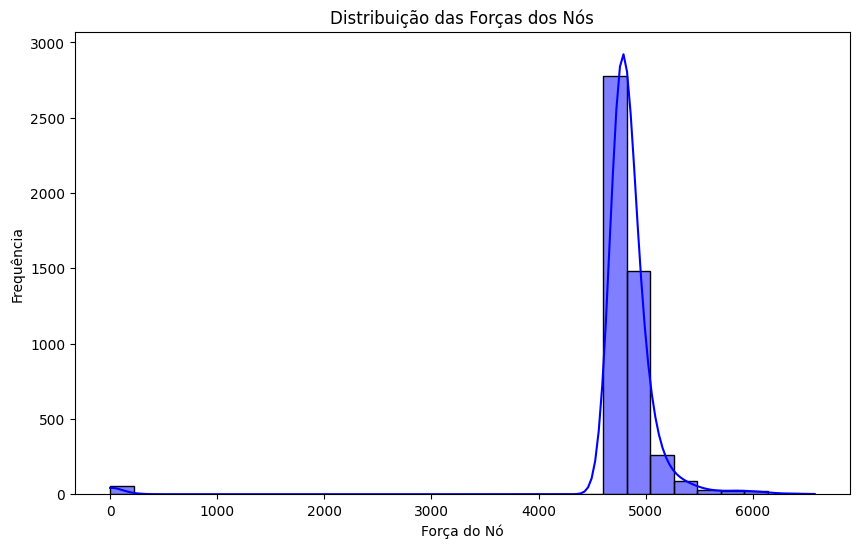

In [5]:
forcas = np.array(g.strength(weights='weight'))
plt.figure(figsize=(10, 6))
sns.histplot(forcas, bins=30, kde=True, color="blue")
plt.title("Distribuição das Forças dos Nós")
plt.xlabel("Força do Nó")
plt.ylabel("Frequência")

In [3]:
arestas_fortes = g.es.select(weight_ge=2)
g = g.subgraph_edges(arestas_fortes, delete_vertices=True)

In [4]:
print(f"Quantidade de nós: {g.vcount()}")
print(f"Quantidade de arestas: {g.ecount()}")

Quantidade de nós: 7307
Quantidade de arestas: 549967


Text(0, 0.5, 'Frequência')

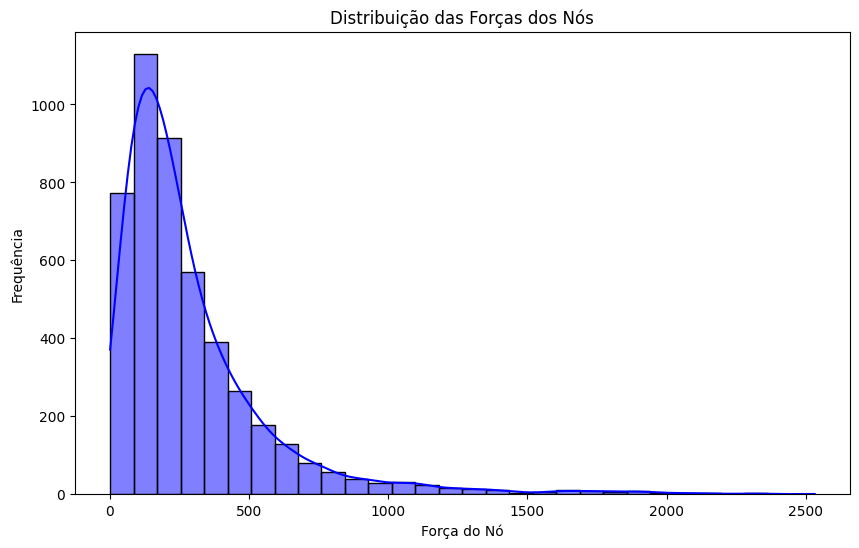

In [15]:
forcas = np.array(g.strength(weights='weight'))
plt.figure(figsize=(10, 6))
sns.histplot(forcas, bins=30, kde=True, color="blue")
plt.title("Distribuição das Forças dos Nós")
plt.xlabel("Força do Nó")
plt.ylabel("Frequência")

---
#### **1.Distribuição de graus**
A distribuição de grau é a fração de vértices da rede que possui um determinado grau. 
O grau de um vértice é o número de conexões (arestas) que ele tem com outros vértices.

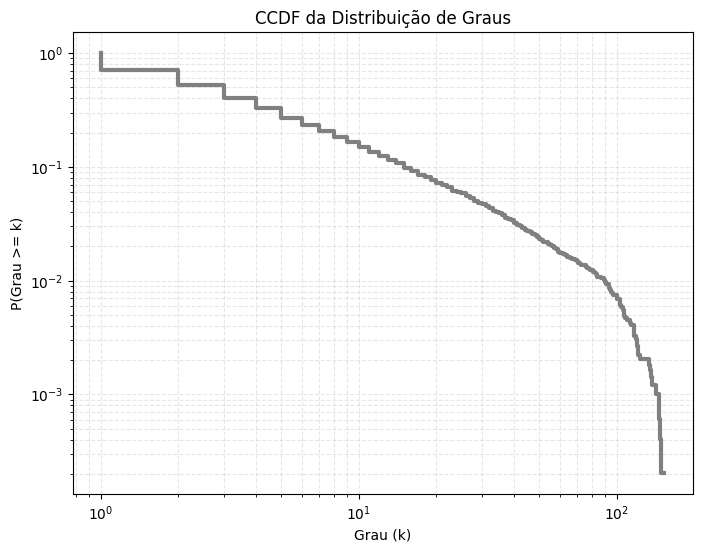

In [4]:
graus = g.degree()
contagem = Counter(graus)
graus_unicos = sorted(contagem.keys(), reverse=True)

y = {}
acumulado = 0
total_nos = g.vcount()

for k in graus_unicos:
    acumulado += contagem[k]
    y[k] = acumulado / total_nos

x_plot = sorted(y.keys())
y_plot = [y[k] for k in x_plot]

plt.figure(figsize=(8, 6))
plt.step(x_plot, y_plot, color='gray', linewidth=3) 
plt.xscale('log')
plt.yscale('log') 
plt.xlabel("Grau (k)")
plt.ylabel("P(Grau >= k)")
plt.title("CCDF da Distribuição de Graus")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

---
#### **2. Coeficiente de clusterização**

In [5]:
cc_values = g.transitivity_local_undirected()

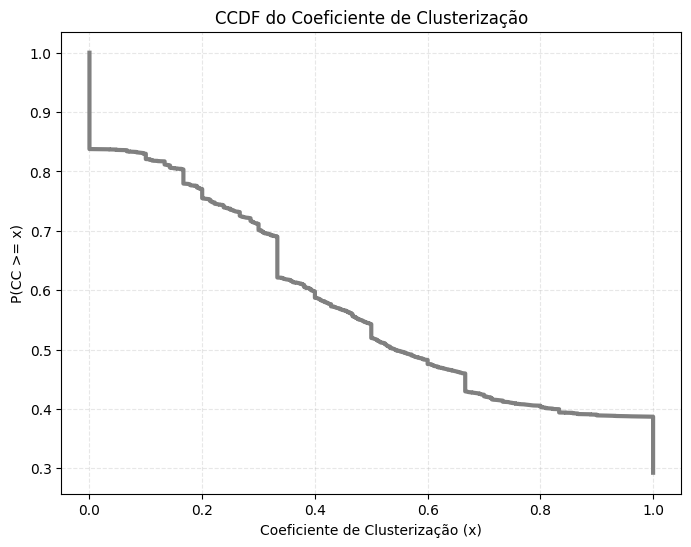

In [6]:
valores_cc = np.sort(cc_values)
n = len(valores_cc)
p_ccdf = np.linspace(1, 1/n, n)

plt.figure(figsize=(8, 6))
plt.plot(valores_cc, p_ccdf, color='gray', linewidth=3) 
plt.xscale('linear') 
#plt.yscale('log')    
plt.xlabel("Coeficiente de Clusterização (x)")
plt.ylabel("P(CC >= x)")
plt.title("CCDF do Coeficiente de Clusterização")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

---
#### **3.Analisando a Centralidade dos Vértices**

A análise de centralidade serve para identificar a importância relativa de cada nó dentro da rede. No contexto de grafos de subreddits, diferentes métricas revelam diferentes comportamentos de influência e compartilhamento de usuários.

O que é Centralidade?
Em termos simples, a centralidade indica o quão "bem posicionado" um vértice está. No entanto, o conceito de "importância" é subjetivo e depende da métrica utilizada:

**Tipos de Centralidade**
1. Centralidade de Grau (Degree Centrality)
- É a medida mais simples e direta. Ela conta o número de conexões (arestas) que um vértice possui.Representa a versatilidade de um subreddit. Um valor alto indica um subreddit que compartilha pelo menos um autor com muitos outros subreddits.

- Significado: "Quem tem mais vizinhos?"

2. Centralidade de Força (Strength / Weighted Degree)
- Diferente do grau, a força leva em conta o peso das arestas. Ela soma o valor de todos os pesos das conexões de um nó. Representa o volume total de "tráfego" de usuários. Um subreddit pode ter poucas conexões, mas se essas conexões tiverem milhares de autores em comum, sua força será altíssima.

- Significado: "Quem tem as conexões mais intensas?"

3. Centralidade de Autovetor (Eigenvector Centrality)
- Esta métrica atribui importância a um nó com base na importância de seus vizinhos. É uma medida de influência "bem relacionada". Identifica subreddits que estão no "core" da rede. Estar conectado a um subreddit gigante aumenta mais a sua centralidade de autovetor do que estar conectado a vários subreddits isolados.

- Significado: "Quem está conectado a pessoas importantes?"

In [5]:
n = g.vcount()
graus = np.array(g.degree())
centralidade_grau = graus / (n - 1)

In [6]:
forcas = np.array(g.strength(weights='weight'))
total_pesos_rede = sum(g.es['weight'])

centralidade_forca = forcas / total_pesos_rede

In [7]:
centralidade_autovetor = g.eigenvector_centrality(weights='weight')

/tmp/ipykernel_4192353/2565167324.py:1: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:102
  centralidade_autovetor = g.eigenvector_centrality(weights='weight')


---
### **Figura da rede com os tamanhos dos vértices proporcionais às centralidades**

In [5]:
g.vs['degree'] = g.degree()
g.vs['eigen'] = g.eigenvector_centrality()

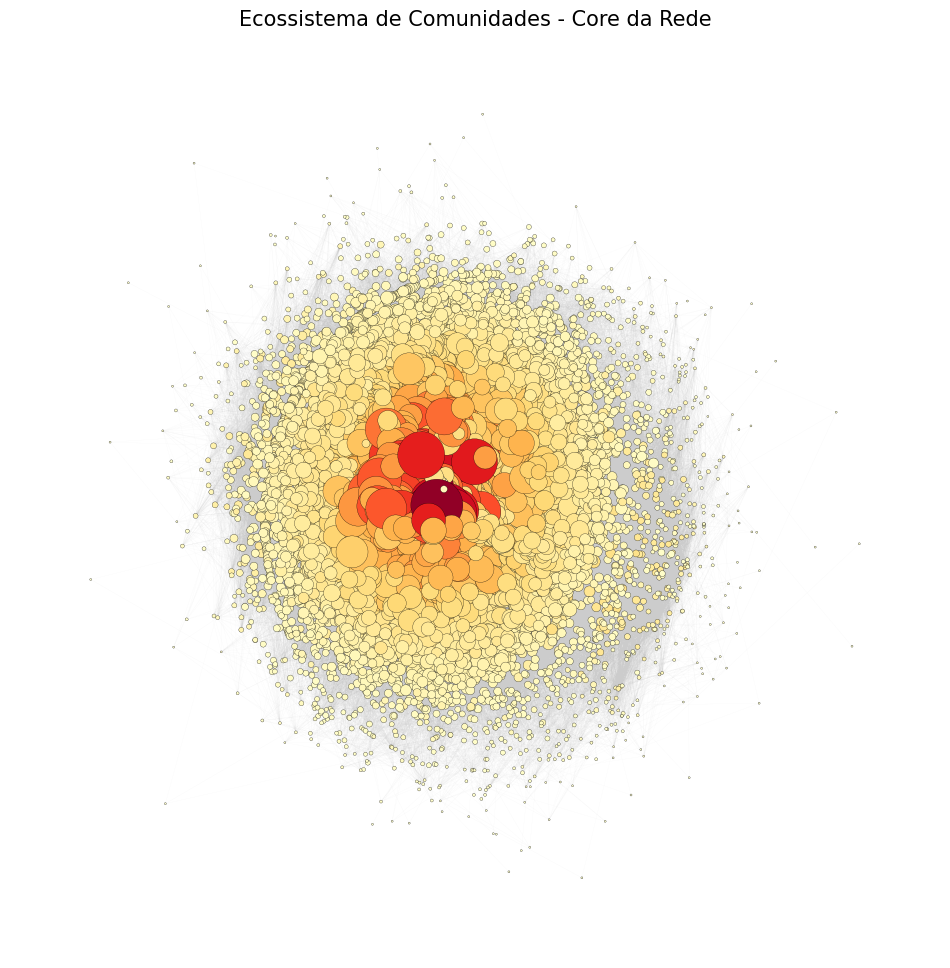

In [6]:
layout = g.layout("kk") 
fig, ax = plt.subplots(figsize=(12, 12))

sizes = [np.sqrt(v) * 50 + 2 for v in g.vs['eigen']]

import matplotlib.cm as cm
norm = plt.Normalize(vmin=min(g.vs['degree']), vmax=max(g.vs['degree']))
colors = [cm.YlOrRd(norm(d)) for d in g.vs['degree']]

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=sizes,
    vertex_color=colors,
    vertex_frame_width=0.2,
    edge_width=0.1, 
    edge_color="#cccccc44",
    vertex_label=None, 
)

plt.title("Ecossistema de Comunidades - Core da Rede", fontsize=15)
plt.axis('off')
plt.show()

In [10]:
import pandas as pd
df_topics = pd.read_csv("../reports/topic_modeling/dicionario_topicos_comunidades.csv")
df_topics.columns

Index(['Topic', 'subreddits_list'], dtype='str')

In [12]:
df_topics.head()

,Topic,subreddits_list
0,-1,"0sanitymemes, 100gecs, 13or30, 2000snostalgia,..."
1,0,"2007scape, 3ds, 7kglobal, adamwarlockmains, al..."
2,1,"accidentalcamouflage, activationsound, airplan..."
3,2,"07nsfw, 18_19, 18nsfw, a_cups, adorableporn, a..."
4,3,"2asia4u, 2bharat4you, 2philippines4u, aajmaine..."


/tmp/ipykernel_1176/569683628.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab20', n_topics)


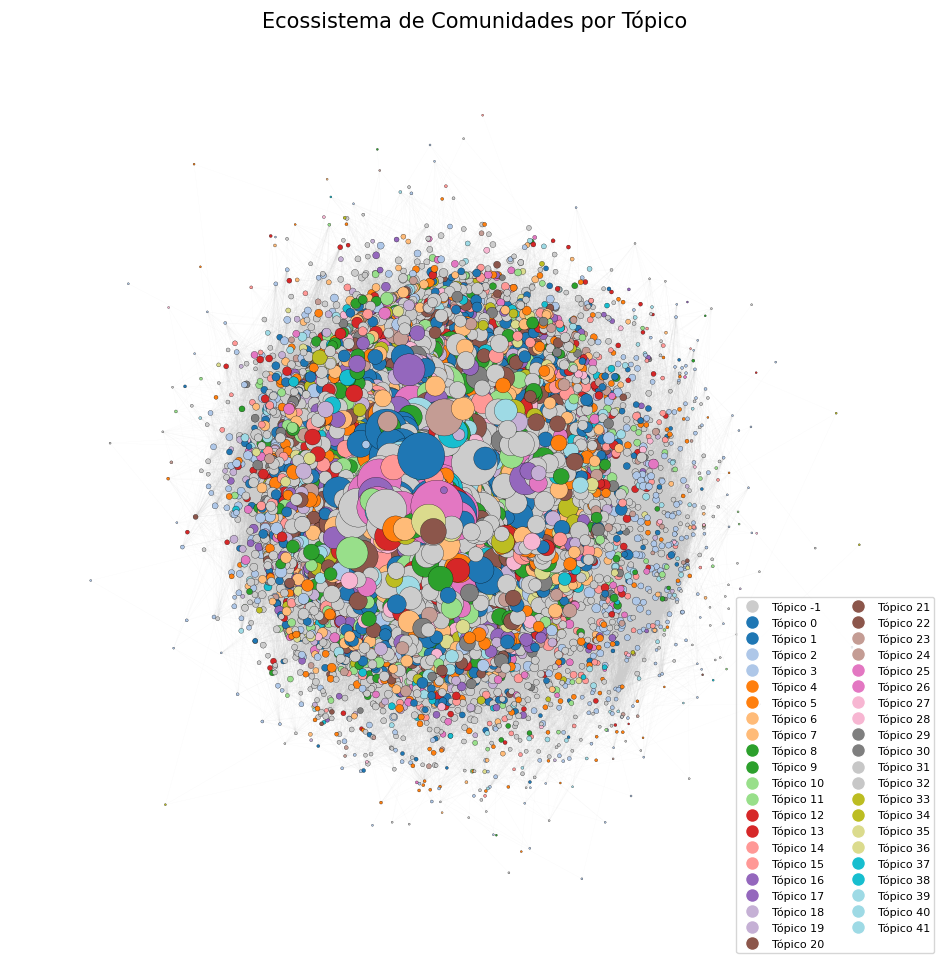

In [13]:
# Expande a lista de subreddits em linhas individuais
df_expanded = df_topics.copy()
df_expanded['subreddits_list'] = df_expanded['subreddits_list'].str.split(', ')
df_expanded = df_expanded.explode('subreddits_list')
df_expanded.columns = ['topic', 'subreddit']

# Cria dicionário subreddit → tópico
subreddit_to_topic = dict(zip(df_expanded['subreddit'], df_expanded['topic']))

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Atribui tópico a cada vértice (-1 para os que não têm)
g.vs['topic'] = [subreddit_to_topic.get(name, -1) for name in g.vs['name']]

# Cria paleta de cores — um por tópico
topics = sorted(set(g.vs['topic']))
n_topics = len(topics)
palette = cm.get_cmap('tab20', n_topics)
topic_to_color = {t: mcolors.to_hex(palette(i)) for i, t in enumerate(topics)}

# Tópico -1 (sem classificação) fica cinza
topic_to_color[-1] = "#cccccc"

colors = [topic_to_color[t] for t in g.vs['topic']]

# Plot
layout = g.layout("kk")
fig, ax = plt.subplots(figsize=(12, 12))

sizes = [np.sqrt(v) * 50 + 2 for v in g.vs['eigen']]

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=sizes,
    vertex_color=colors,
    vertex_frame_width=0.2,
    edge_width=0.1,
    edge_color="#cccccc44",
    vertex_label=None,
)

# Legenda
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=topic_to_color[t], markersize=10, label=f'Tópico {t}')
           for t in topics]
ax.legend(handles=handles, loc='lower right', fontsize=8, ncol=2)

plt.title("Ecossistema de Comunidades por Tópico", fontsize=15)
plt.axis('off')
plt.show()

In [12]:
df_depths = df.groupby('subreddit')['depth'].min().reset_index()
depth_map = dict(zip(df_depths['subreddit'], df_depths['depth']))

vertex_colors = []
for name in g.vs['name']:
    depth = depth_map.get(name, 1) # Padrão 1 se não encontrar
    if depth == 0:
        vertex_colors.append("#e74c3c") # Vermelho vibrante para sementes
    else:
        vertex_colors.append("#3498db") # Azul para o restante

# 3. Preparar o Plot
layout = g.layout("kk") 
fig, ax = plt.subplots(figsize=(12, 12))

# Mantendo sua lógica de tamanho por Eigenvector
sizes = [np.sqrt(v) * 50 + 2 for v in g.vs['eigen']]

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=sizes,
    vertex_color=vertex_colors, # AQUI USAMOS A NOVA LISTA DE CORES
    vertex_frame_width=0.2,
    edge_width=0.1, 
    edge_color="#cccccc44",
    vertex_label=None, 
)

# Adicionar uma legenda manual para facilitar a leitura
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Sementes (Depth 0)', 
           markerfacecolor='#e74c3c', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Descobertos (Depth > 0)', 
           markerfacecolor='#3498db', markersize=10)
]
ax.legend(handles=legend_elements, loc='upper right')

plt.title("Ecossistema: Diferenciação entre Sementes e Expansão", fontsize=15)
plt.axis('off')
plt.show()


NameError: name 'df' is not defined